# 读取后台 DE 仿真结果（analysis_result_*.npz）

本 notebook 读取后台脚本生成的 `analysis_result_run_<i>.npz`，
并参照原 `20260730.ipynb` / `sim_script_legacy/DEMO.ipynb` 对延迟电子（DE）
堆叠信号做 score 优化与数据筛选分析。

当前分析需要同时包含 DE 与 CEvNS 的 `pattern`、`st_cor`、`area`。
如果结果目录里缺少 `cevns_pattern`，请使用
`scripts/run_20260829_background_cevns_with_pattern.py` 重新生成结果。

每个结果文件应包含以下字段：

| 字段 | 说明 |
|---|---|
| `de_st_cor` | 每个堆叠事件的 space-time correlation |
| `de_pattern` | pattern likelihood |
| `de_area` | 每个事件的总 PE（area） |
| `cevns_st_cor` | 每个 CEvNS 事件的 space-time correlation |
| `cevns_pattern` | CEvNS pattern likelihood |
| `cevns_area` | 每个 CEvNS 事件的总 PE（area） |
| `time_range_s` | 该 muon 文件的模拟时间窗 |
| `n_de` | 该文件保留的 DE 事件数 |
| `input_file` | 对应 muon 输入文件路径 |


In [1]:
# ============================================================
# 1) 导入 + 配置结果目录 + 读取所有 analysis_result_*.npz
# ============================================================
import os
from pathlib import Path
import glob

import numpy as np
import matplotlib.pyplot as plt

# 后台脚本的输出目录（--out-dir 参数）。
# 优先使用包含 cevns_pattern 的新结果目录；如尚未生成，可先运行：
#   python scripts/run_20260829_background_cevns_with_pattern.py
RESULT_DIR_CANDIDATES = [
    Path("output/20260829_cevns_with_pattern"),
    Path("../output/20260829_cevns_with_pattern"),
]
RESULT_DIR = next(
    (p for p in RESULT_DIR_CANDIDATES if p.exists()),
    Path("../output/run_muon6_gamma10"),
)
RESULT_DIR = RESULT_DIR.resolve()
print("结果目录:", RESULT_DIR)
assert RESULT_DIR.exists(), f"未找到输出目录 {RESULT_DIR}，请先运行后台脚本。"

# 需要的数组键；cevns_pattern 也必须从导入的 npz key 中读取，
# 不要在这里用 pattern_likelihood 重算。
KEYS = [
    "de_st_cor",
    "de_pattern",
    "de_area",
    "cevns_st_cor",
    "cevns_pattern",
    "cevns_area",
]

# 收集所有 analysis_result_*.npz
npz_files = sorted(glob.glob(str(RESULT_DIR / "analysis_result_*.npz")))
print(f"找到 {len(npz_files)} 个结果文件")
assert npz_files, "该目录下没有 analysis_result_*.npz。"
for f in npz_files:
    print(" ", Path(f).name)

# 预先检查第一个文件的字段，确保后续加载不会因为缺少 cevns_pattern 而在中途失败。
with np.load(npz_files[0], allow_pickle=False) as _d:
    _available_keys = set(_d.files)
_missing_keys = [k for k in KEYS if k not in _available_keys]
if _missing_keys:
    raise FileNotFoundError(
        f"当前结果文件缺少字段 {_missing_keys}。\n"
        "请改用 scripts/run_20260829_background_cevns_with_pattern.py 生成结果，"
        "或把 RESULT_DIR 指向包含 cevns_pattern 的目录。"
    )
print("已确认字段:", sorted(k for k in KEYS if k in _available_keys))


结果目录: /home/leiyang/TPC_DE_SIm-test/output/run_muon6_gamma10
找到 50 个结果文件
  analysis_result_run_00.npz
  analysis_result_run_01.npz
  analysis_result_run_02.npz
  analysis_result_run_03.npz
  analysis_result_run_04.npz
  analysis_result_run_05.npz
  analysis_result_run_06.npz
  analysis_result_run_07.npz
  analysis_result_run_08.npz
  analysis_result_run_09.npz
  analysis_result_run_10.npz
  analysis_result_run_11.npz
  analysis_result_run_12.npz
  analysis_result_run_13.npz
  analysis_result_run_14.npz
  analysis_result_run_15.npz
  analysis_result_run_16.npz
  analysis_result_run_17.npz
  analysis_result_run_18.npz
  analysis_result_run_19.npz
  analysis_result_run_20.npz
  analysis_result_run_21.npz
  analysis_result_run_22.npz
  analysis_result_run_23.npz
  analysis_result_run_24.npz
  analysis_result_run_25.npz
  analysis_result_run_26.npz
  analysis_result_run_27.npz
  analysis_result_run_28.npz
  analysis_result_run_29.npz
  analysis_result_run_30.npz
  analysis_result_run_31.npz

FileNotFoundError: 当前结果文件缺少字段 ['cevns_pattern']。
请改用 scripts/run_20260829_background_cevns_with_pattern.py 生成结果，或把 RESULT_DIR 指向包含 cevns_pattern 的目录。

In [ ]:
# ============================================================
# 2) 逐个加载 npz，合并所有文件的 DE 数组
#    使用 with np.load(...) 及时释放文件句柄，避免内存堆积
# ============================================================
parts = {k: [] for k in KEYS}
total_time = 0.0
n_per_file = []

for fp in npz_files:
    with np.load(fp, allow_pickle=False) as d:
        for k in KEYS:
            parts[k].append(d[k])
        total_time += float(d["time_range_s"])
        n_per_file.append(int(d["n_de"]))

# 合并成一个大的结构化数组
de = {k: np.concatenate(parts[k]) if len(parts[k]) > 1 else parts[k][0]
      for k in KEYS}

# 释放中间列表引用
del parts

print(f"合并后 DE 事件总数: {len(de['de_area'])}")
print(f"合并后 CEvNS 事件总数: {len(de['cevns_area'])}")
print(f"总模拟时间: {total_time:.3f} s")
print(f"每文件事件数: {n_per_file}")

# 方便后续使用的别名（与原 notebook 变量名一致）
st_cor   = de["de_st_cor"]
pattern  = de["de_pattern"]
DE_area  = de["de_area"]

cevns_st_cor  = de["cevns_st_cor"]
cevns_pattern = de["cevns_pattern"]  # 直接取自导入数据 key
cevns_area    = de["cevns_area"]



合并后 DE 事件总数: 263382148
总模拟时间: 500000.000 s
每文件事件数: [5373384, 5278541, 5217751, 5247987, 5252737, 5336760, 5220449, 5147060, 5262378, 5308095, 5339939, 5340674, 5224679, 5231055, 5314655, 5242929, 5306054, 5251044, 5179257, 5196322, 5299440, 5294920, 5346441, 5222317, 5256427, 5262620, 5273366, 5311057, 5270296, 5189747, 5257152, 5277088, 5265494, 5315508, 5199914, 5235341, 5285912, 5295086, 5306704, 5239250, 5202127, 5214109, 5293839, 5327222, 5281291, 5227981, 5212802, 5289624, 5322446, 5334877]


In [ ]:
# ============================================================
# 3) 加载 PMT 几何布局（用于 pattern_plot），并复刻原 notebook 的绘图函数
# ============================================================
import matplotlib as mpl
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid

# PMT 布局 dtype：与 relics_de_sim/constants.PMT_DTYPE 一致
PMT_DTYPE = np.dtype([
    ("ChannelID", "<i4"),
    ("x", "<f8"),
    ("y", "<f8"),
    ("z", "<f8"),
    ("rot_x", "<f8"),
    ("rot_y", "<f8"),
    ("rot_z", "<f8"),
])

# 定位 PMT 布局文件（自动搜索项目根，兼容 Windows/Linux/服务器）
def _find_pmt_layout():
    for cand in (Path.cwd(),
                 Path.cwd() / "TPC_DE_SIm-test",
                 Path.cwd().parent,
                 Path.cwd().parent / "TPC_DE_SIm-test"):
        p = cand / "LCE_info" / "topPMTs.txt"
        if p.exists():
            return cand / "LCE_info"
    raise FileNotFoundError("未找到 LCE_info/topPMTs.txt，请检查项目路径。")

_lce_dir = _find_pmt_layout()
pmt_top = np.loadtxt(_lce_dir / "topPMTs.txt", dtype=PMT_DTYPE)
print("pmt_top path:", _lce_dir / "topPMTs.txt", "| shape:", pmt_top.shape)


def pattern_plot(phe_pmt, electron=[], pos_recons=[], pmt_info=pmt_top,
                 title="", savefig=False):
    """绘制单个 DE 堆叠事件的 PMT 光斑（复刻原 notebook）。"""
    phe_pmt = np.asarray(phe_pmt)
    phe_pmt = np.nan_to_num(phe_pmt, nan=0.0)

    max_val = phe_pmt.max()
    if max_val <= 1:
        norm = mpl.colors.Normalize(vmin=0, vmax=max(1, max_val))
    else:
        try:
            norm = mpl.colors.LogNorm(vmin=1, vmax=max_val, clip=True)
        except ValueError:
            norm = mpl.colors.Normalize(vmin=0, vmax=max_val)
    cmap = mpl.cm.viridis

    fig = plt.figure(figsize=(7, 6))
    grid = ImageGrid(fig, 111, (1, 1))

    for pmt_id in range(len(pmt_info)):
        pmt = pmt_info[pmt_id]
        if phe_pmt[pmt_id] < 0.1:
            pmt_color = 'white'
        else:
            pmt_color = cmap(norm(phe_pmt[pmt_id]))
        grid[0].text(pmt['x'], pmt['y'], str(round(phe_pmt[pmt_id], 1)),
                     ha='center', va='center', fontsize=15)
        border = Rectangle(xy=(pmt['x'] - 1.27, pmt['y'] - 1.27), width=2.54,
                           height=2.54, angle=pmt['rot_z'],
                           rotation_point='center', fc='none', ec='black',
                           lw=1, alpha=1)
        grid[0].add_patch(border)
        grid[0].add_patch(Rectangle(xy=(pmt['x'] - 1.27, pmt['y'] - 1.27),
                                    width=2.54, height=2.54, angle=pmt['rot_z'],
                                    rotation_point='center', fc=pmt_color,
                                    alpha=1))
    if len(electron) > 0:
        grid[0].plot(electron['xd'] / 10, electron['yd'] / 10, 'ro',
                     markersize=12, label='Position')
    if len(pos_recons) > 0:
        grid[0].plot(pos_recons[0] / 10, pos_recons[0] / 10, 'b*',
                     markersize=12, label='Recon Position')
    grid[0].axis('equal')
    grid[0].set_xlabel('x/cm')
    grid[0].set_ylabel('y/cm')
    grid[0].legend()
    grid[0].set_title(title)
    if savefig:
        plt.savefig(title + ".png")
    plt.show()
    return 0


pmt_top path: /home/leiyang/TPC_DE_SIm-test/LCE_info/topPMTs.txt | shape: (28,)


/tmp/ipykernel_458841/1660889733.py:11: RuntimeWarning: divide by zero encountered in log
  h = ax.hist2d(np.log(st_cor), pattern, bins=(x_bins, y_bins),


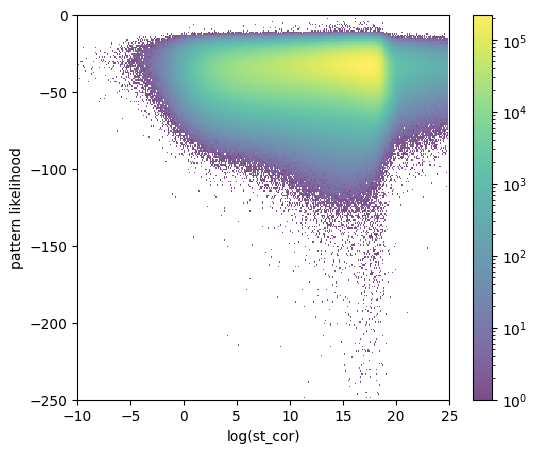

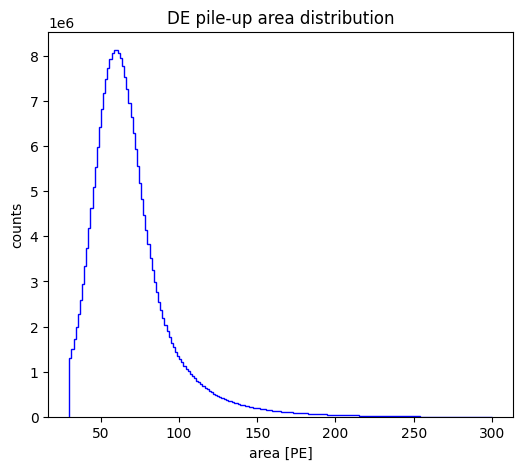

/tmp/ipykernel_458841/1660889733.py:30: RuntimeWarning: divide by zero encountered in log
  h = ax.hist2d(np.log(st_cor), DE_area, bins=(x_bins, 200),


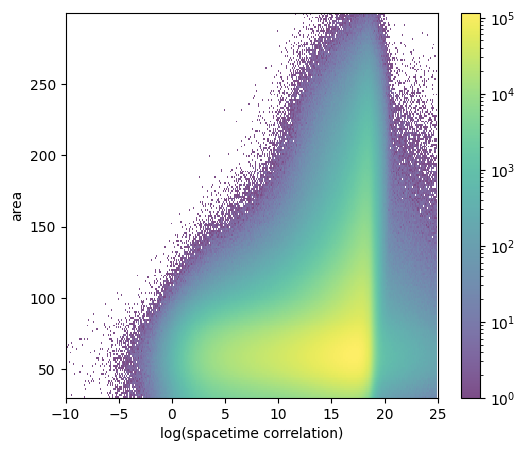

In [ ]:
# ============================================================
# 4) DE 关键分布画图（对照原 notebook）
# ============================================================
from matplotlib.colors import LogNorm

# --- 4.1 log(st_cor) vs pattern likelihood 2D 直方图 ---
x_bins = np.arange(-10, 25, 0.1)
y_bins = np.arange(-250, 0, 1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(st_cor), pattern, bins=(x_bins, y_bins),
              cmap='viridis', norm=LogNorm(), alpha=0.7)
ax.set_xlabel('log(st_cor)')
ax.set_ylabel('pattern likelihood')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10, 25)
plt.ylim(-250, 0)
plt.show()

# --- 4.2 DE area 分布 ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist(DE_area, bins=200, histtype='step', color='blue')
ax.set_xlabel('area [PE]')
ax.set_ylabel('counts')
ax.set_title('DE pile-up area distribution')
plt.show()

# --- 4.3 log(st_cor) vs DE area 2D ---
fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(st_cor), DE_area, bins=(x_bins, 200),
              cmap='viridis', norm=LogNorm(), alpha=0.7)
ax.set_xlabel('log(spacetime correlation)')
ax.set_ylabel('area')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10, 25)
plt.show()


/tmp/ipykernel_458841/331177433.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b--" (-> color='b'). The keyword argument will take precedence.
  plt.plot(x_fit, y_fit_roi, 'b--', linewidth=2, color='b',


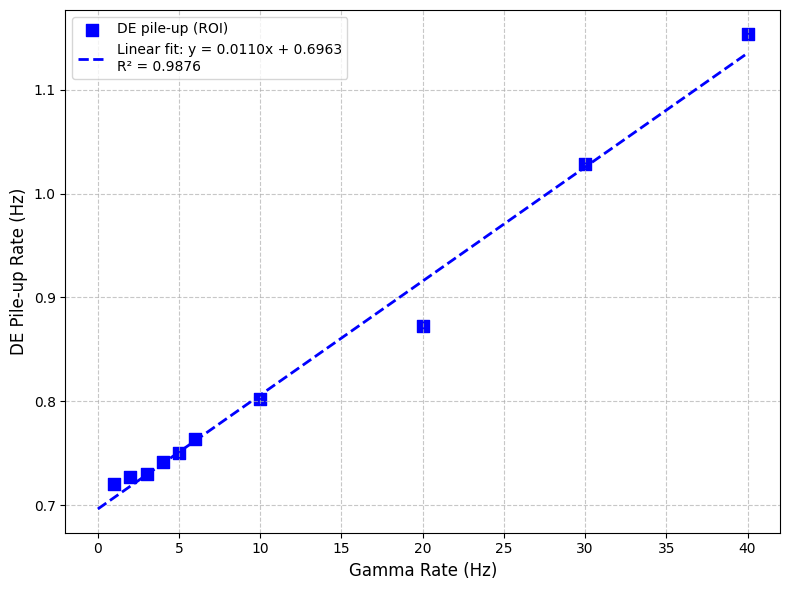

拟合方程: y = 0.010975x + 0.696305
R² = 0.987617
斜率 = 0.010975 (Hz⁻¹)
截距 = 0.696305


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 数据提取
gamma_rate = [1, 2, 3, 4, 5, 6, 10, 20, 30, 40]  # 横轴数据 (Gamma rate in Hz)
de_pile_up_total = [239.6, 244.3, 249.1, 253.8, 258.2, 263.0, 281.7,325.8, 371.8, 411.675]  # 纵轴数据 (DE pile-up total)
de_pile_up_roi = [0.720, 0.727, 0.730, 0.742, 0.750, 0.764, 0.802, 0.873, 1.029, 1.154]  # 纵轴数据 (DE pile-up ROI)

# 进行线性拟合 (对 ROI 数据)
slope_roi, intercept_roi, r_value_roi, p_value_roi, std_err_roi = stats.linregress(gamma_rate, de_pile_up_roi)
# 生成拟合直线
x_fit = np.linspace(0, 40, 100)
y_fit_roi = slope_roi * x_fit + intercept_roi

# 创建图形
plt.figure(figsize=(8, 6))

# 绘制数据点
plt.scatter(gamma_rate, de_pile_up_roi, marker='s', color='b', s=80, label='DE pile-up (ROI)')

# 绘制拟合直线
plt.plot(x_fit, y_fit_roi, 'b--', linewidth=2, color='b',
         label=f'Linear fit: y = {slope_roi:.4f}x + {intercept_roi:.4f}\nR² = {r_value_roi**2:.4f}')

# 添加标题和标签
plt.xlabel('Gamma Rate (Hz)', fontsize=12)
plt.ylabel('DE Pile-up Rate (Hz)', fontsize=12)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 设置坐标轴范围
# plt.xlim(0.5, 5.5)
# plt.ylim(0.71, 0.76)  # 调整纵轴范围以便更好显示数据点

# 显示图例
plt.legend(loc='upper left')

# 显示图形
plt.tight_layout()
plt.show()

# 打印拟合参数
print(f"拟合方程: y = {slope_roi:.6f}x + {intercept_roi:.6f}")
print(f"R² = {r_value_roi**2:.6f}")
print(f"斜率 = {slope_roi:.6f} (Hz⁻¹)")
print(f"截距 = {intercept_roi:.6f}")

/tmp/ipykernel_458841/637071925.py:18: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot(x_fit, y_fit_roi, 'r--', linewidth=2, color='r',


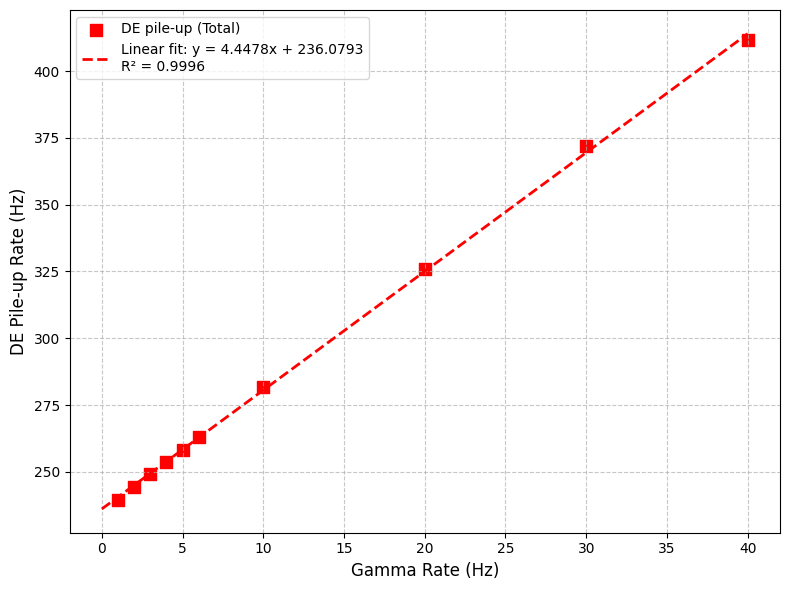

拟合方程: y = 4.447786x + 236.079293
R² = 0.999566
斜率 = 4.447786 (Hz⁻¹)
截距 = 236.079293


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 进行线性拟合 (对 ROI 数据)
slope_roi, intercept_roi, r_value_roi, p_value_roi, std_err_roi = stats.linregress(gamma_rate, de_pile_up_total)
# 生成拟合直线
x_fit = np.linspace(0, 40, 100)
y_fit_roi = slope_roi * x_fit + intercept_roi

# 创建图形
plt.figure(figsize=(8, 6))

# 绘制数据点
plt.scatter(gamma_rate, de_pile_up_total, marker='s', color='r', s=80, label='DE pile-up (Total)')

# 绘制拟合直线
plt.plot(x_fit, y_fit_roi, 'r--', linewidth=2, color='r',
         label=f'Linear fit: y = {slope_roi:.4f}x + {intercept_roi:.4f}\nR² = {r_value_roi**2:.4f}')

# 添加标题和标签
plt.xlabel('Gamma Rate (Hz)', fontsize=12)
plt.ylabel('DE Pile-up Rate (Hz)', fontsize=12)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 设置坐标轴范围
# plt.xlim(0.5, 5.5)
# plt.ylim(0.71, 0.76)  # 调整纵轴范围以便更好显示数据点

# 显示图例
plt.legend(loc='upper left')

# 显示图形
plt.tight_layout()
plt.show()

# 打印拟合参数
print(f"拟合方程: y = {slope_roi:.6f}x + {intercept_roi:.6f}")
print(f"R² = {r_value_roi**2:.6f}")
print(f"斜率 = {slope_roi:.6f} (Hz⁻¹)")
print(f"截距 = {intercept_roi:.6f}")

In [ ]:
# # ============================================================
# # 新定义的 pattern_score：
# #   对每个 DE 事件，选出 de_pe_by_area 中 PE 最大的 3 个 PMT，
# #   计算这 3 个 PMT 两两之间的平均距离（基于 pmt_top 的 x, y 位置）。
# # ============================================================
# import numpy as np

# # pmt_top 各 PMT 的坐标
# pmt_xy = np.stack([pmt_top["x"], pmt_top["y"]], axis=1)   # (N_pmt, 2)


# def pattern_score_one(pe_vec, pmt_xy=pmt_xy, n_top=3):
#     """对单个事件：取 PE 最大的 n_top 个 PMT，返回它们两两平均距离。"""
#     # 选出 PE 最大的 n_top 个 PMT 下标
#     top_idx = np.argsort(pe_vec[:28])[-n_top:]
#     idx3 = top_idx
#     # 只取多个PMT两两距离的平均（需要 n_top>=2）
#     if len(idx3) < 2:
#         return 0.0
#     pts = pmt_xy[idx3]                                   # 所选 PMT 的 (x, y)
#     # 两两欧氏距离矩阵，取上三角的平均
#     d = np.sqrt(((pts[:, None, :] - pts[None, :, :]) ** 2).sum(axis=2))
#     n = len(pts)
#     # 取严格上三角非零距离的平均
#     iu = np.triu_indices(n, k=1)
#     return float(d[iu].mean())

# from tqdm import tqdm
# # 对整个 DE 事件集合计算 pattern_score
# pattern_score = np.array([pattern_score_one(DE_pe_by_area[i]) for i in tqdm(range(len(DE_pe_by_area)))])

# print("pattern_score: shape =", pattern_score.shape)
# print("pattern_score: min = {:.3f}, max = {:.3f}, mean = {:.3f}".format(
#     pattern_score.min(), pattern_score.max(), pattern_score.mean()))

# # 展示分布
# fig, ax = plt.subplots(figsize=(6, 5))
# ax.hist(pattern_score, bins=100, histtype='step', color='green')
# ax.set_xlabel('pattern_score (mean pair distance of top-3 PMTs, cm)')
# ax.set_ylabel('counts')
# ax.set_title('pattern_score distribution')
# plt.show()


In [ ]:
# import sys
# from pathlib import Path
# import importlib
# import numpy as np
# import matplotlib.pyplot as plt
# import os

# # 确保能 import 包（在仓库根运行时通常为 '.'）
# sys.path.append('/home/leiyang/TPC_DE_SIm-test')
# from relics_de_sim.config import DESimConfig
# from relics_de_sim.pipeline import Pipeline
# import relics_de_sim as rds
# importlib.reload(rds)
# print('relics_de_sim package imported')

In [ ]:
# cfg_rel = Path('../configs/muon_only.yaml')
# if not cfg_rel.exists():
#     raise FileNotFoundError(f'未找到配置文件: {cfg_rel.resolve()}')
# cfg = DESimConfig.from_yaml(cfg_rel)
# print('Loaded YAML source:', cfg.source_yaml)
# print('Resolved paths:')
# print(' muon_track_dir:', cfg.paths.muon_track_dir)
# print(' lce_value:', cfg.paths.lce_value)
# print(' position_reconstruction_model:', cfg.paths.position_reconstruction_model)
# print('Simulation params: dead_time_s=', cfg.simulation.dead_time_s, ', muon_rate_hz=', cfg.simulation.muon_rate_hz)

In [ ]:

# muon_root = Path("/home/leiyang/TPC_DE_SIm-test/muon_track")
# cfg.paths.muon_track_dir = str(muon_root)

In [ ]:
# from relics_de_sim import DESimConfig, Pipeline
# cfg = DESimConfig.from_yaml('../configs/cevns_sim.yaml')
# print('cevns_e_spectrum:', cfg.paths.cevns_e_spectrum)

In [ ]:
# def collect_event_files(base_dir, event_type):
#     base = Path(base_dir)
#     event_dir = base / f"{event_type}_events"
#     matches = sorted(event_dir.glob(f"{event_type}_events.*.npy")) if event_dir.exists() else []
#     if not matches:
#         matches = sorted(base.rglob(f"{event_type}_events.*.npy"))
#     if not matches:
#         matches = sorted(base.rglob("*.npy"))
#     return matches

# muon_files = collect_event_files(muon_root, "muon")
# # gamma_files = collect_event_files(muon_root, "gamma")

# muon_paths = [str(p) for p in muon_files[1:3]]
# # gamma_paths = [str(p) for p in gamma_files]
# load_files = muon_paths 

# pipe_cevns = Pipeline(cfg, rng=np.random.default_rng(7))
# pipe_cevns.load_muon_tracks(load_files)
# print("loaded file count:", len(load_files))
# print(load_files)

In [ ]:
# cfg.simulation.muon_rate_hz = 6

In [ ]:
# pipe_cevns.time_range_s

In [ ]:
# try:
#     pipe_cevns.simulate_cevns()
#     for arr in pipe_cevns.cevns_points:
#         if len(arr):
#             print(f'n_e={int(arr["num_e"][0])}: {len(arr)} events')
# except ImportError as exc:
#     print('CNN inference unavailable:', exc)

In [ ]:
# arr = np.concatenate(pipe_cevns.cevns_points)

In [ ]:
# cevns_pe_by_area = arr['pe_by_area']
# cevns_st_cor = arr['st_cor']
# cevns_area = np.sum(arr['pe_by_area'],axis=1)

In [ ]:

# cevns_pattern_score = np.array([pattern_score_one(cevns_pe_by_area[i]) for i in tqdm(range(len(cevns_pe_by_area)))])

In [ ]:
# x_bins = np.arange(-10,25,0.1)

# fig, ax = plt.subplots(figsize=(6, 5))
# h = ax.hist2d(np.log(cevns_st_cor), cevns_pattern_score, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
# h = ax.hist2d(np.log(st_cor), pattern_score, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
# ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('pattern_score')
# plt.colorbar(h[3], ax=ax)
# plt.xlim(-10,25)

# plt.show()

In [ ]:
cevns_ROI_mask = (cevns_area>120) & (cevns_area<300)
DE_ROI_mask = (DE_area>120) & (DE_area<300)

/tmp/ipykernel_458841/660514675.py:4: RuntimeWarning: divide by zero encountered in log
  h = ax.hist2d(np.log(cevns_st_cor), cevns_area, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
/tmp/ipykernel_458841/660514675.py:5: RuntimeWarning: divide by zero encountered in log
  h = ax.hist2d(np.log(st_cor), DE_area, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)


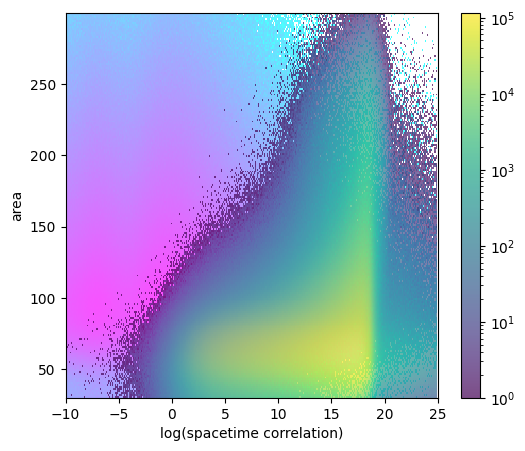

In [ ]:
x_bins = np.arange(-10,25,0.1)

fig, ax = plt.subplots(figsize=(6, 5))
h = ax.hist2d(np.log(cevns_st_cor), cevns_area, bins = (x_bins, 200), cmap='cool', norm=LogNorm(),alpha = 0.7)
h = ax.hist2d(np.log(st_cor), DE_area, bins = (x_bins, 200), cmap='viridis', norm=LogNorm(),alpha = 0.7)
ax.set_xlabel('log(spacetime correlation)'); ax.set_ylabel('area')
plt.colorbar(h[3], ax=ax)
plt.xlim(-10,25)

plt.show()

In [ ]:
def calculate_score(st_cor, area, k_area):
    return k_area * area - np.log(st_cor)

In [ ]:
# from tqdm import tqdm
# exposure = []

# k_area_list = np.arange(-0.1,0.4,0.005)
# k_list = []
# exposure_k = []
# for k in tqdm(k_area_list):
#     score_cevns = calculate_score(cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area = k)
#     score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area = k)
#     valid_score_cevns = score_cevns[~np.isnan(score_cevns)]
#     valid_score_DE = score_DE[~np.isnan(score_DE)]   
#     x = np.percentile(valid_score_DE, 100-0.001)
#     exposure_k.append(len(valid_score_cevns[valid_score_cevns>x])/len(valid_score_cevns))
#     k_list.append([k,x])
#     exposure.append(exposure_k)
# exposure = np.array(exposure)

In [ ]:
# plt.figure()

# plt.plot(k_area_list, exposure_k, marker='o')
# plt.xlabel(r"$k_{area}$")
# plt.ylabel("Exposure")
# plt.tight_layout()

# plt.show()

# index_of_max = np.argmax(exposure)
# print(k_list[index_of_max],np.max(exposure))
# k_area, b = k_list[index_of_max]
# b = -b

In [ ]:
def plot_area_spectrum(area, total_time, LXe_mass, bins, **kwargs):
    count, bins = np.histogram(area, bins=bins)
    bin_width = np.diff(bins)
    freq = 86400 * count / (bin_width) / total_time / LXe_mass
    ax = plt.gca()
    ax.stairs(freq, edges=bins, **kwargs)
    ax.set_xlabel(r'$\mathrm{area\ [PE]}$')
    ax.set_ylabel(r'$\mathrm{Freq\ [counts \cdot day^{-1} \cdot kg^{-1} \cdot PE^{-1}]}$')
    return ax, count, bins

总模拟时间 total_time = 500000.000 s，DE 事件数 = 263382148


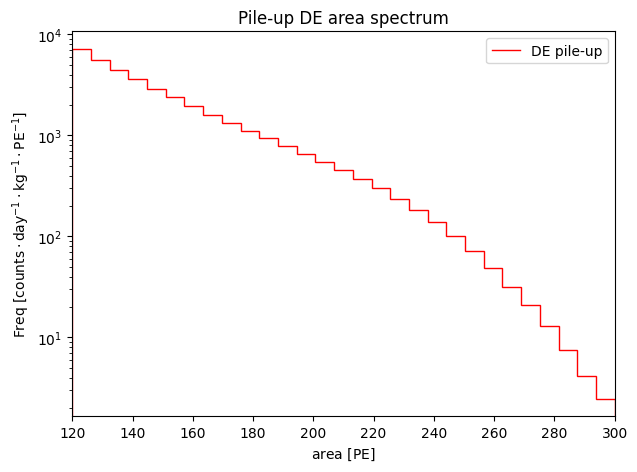

DE rate (total): 526.764 Hz
DE rate (ROI): 23.904 Hz
DE 1年事件数(无cut): 7.538e+08


In [ ]:
# ============================================================
# 6) score / cut / DE area 谱（对照原 notebook 末尾分析）
#    注意：原分析同时需要 CEvNS 信号样本；这里仅演示基于 DE 的部分，
#    若你也有对应的 CEvNS 结果可另加载后套用相同公式。
# ============================================================

# ---------- 例子 2：DE area 谱（频率已按 质量*时间 归一化为 Hz/(kg*PE)）----------
LXe_mass = 8.98
print(f"总模拟时间 total_time = {total_time:.3f} s，DE 事件数 = {len(DE_area)}")

fig, ax = plt.subplots(figsize=(7, 5))
bins = np.linspace(120, 300, 30)
plot_area_spectrum(DE_area, total_time, LXe_mass, bins,
                   label='DE pile-up', color='red')
plt.yscale('log')
plt.legend()
plt.title('Pile-up DE area spectrum')
plt.xlim(120, 300)
plt.show()

# 简单统计
print("DE rate (total): {:.3f} Hz".format(len(DE_area) / total_time))
print("DE rate (ROI): {:.3f} Hz".format(len(DE_area[DE_ROI_mask]) / total_time))
print("DE 1年事件数(无cut): {:.3e}".format((len(DE_area[DE_ROI_mask]) / total_time) * 3600 * 24 * 365))


In [ ]:
k_area = 0

score_DE = calculate_score(st_cor[DE_ROI_mask], DE_area[DE_ROI_mask], k_area)
score_DE = score_DE[~np.isnan(score_DE)]
score_CEvNS = calculate_score(cevns_st_cor[cevns_ROI_mask], cevns_area[cevns_ROI_mask], k_area)
score_CEvNS = score_CEvNS[~np.isnan(score_CEvNS)]

/tmp/ipykernel_458841/1493289449.py:2: RuntimeWarning: divide by zero encountered in log
  return k_area * area - np.log(st_cor)


In [ ]:
thresholds = np.arange(-40, 50, 0.2)  # 你可以调整这个范围和步长以适应你的数据

# 初始化两个比例的列表
left_DE_ratios = []
right_cevns_ratios = []

# 计算每个阈值下的比例
for threshold in thresholds:
    left_DE_ratio = np.sum(score_DE < threshold) / len(score_DE)
    right_cevns_ratio = np.sum(score_CEvNS > threshold) / len(score_CEvNS)
    
    left_DE_ratios.append(left_DE_ratio)
    right_cevns_ratios.append(right_cevns_ratio)

In [ ]:
left_DE_ratios = np.array(left_DE_ratios)

if np.any(left_DE_ratios > 1-0.00001):
    index = np.argmax(left_DE_ratios > 1-0.00001)
else:
    index = -1  # 或者 None，表示未找到

print(index)

195


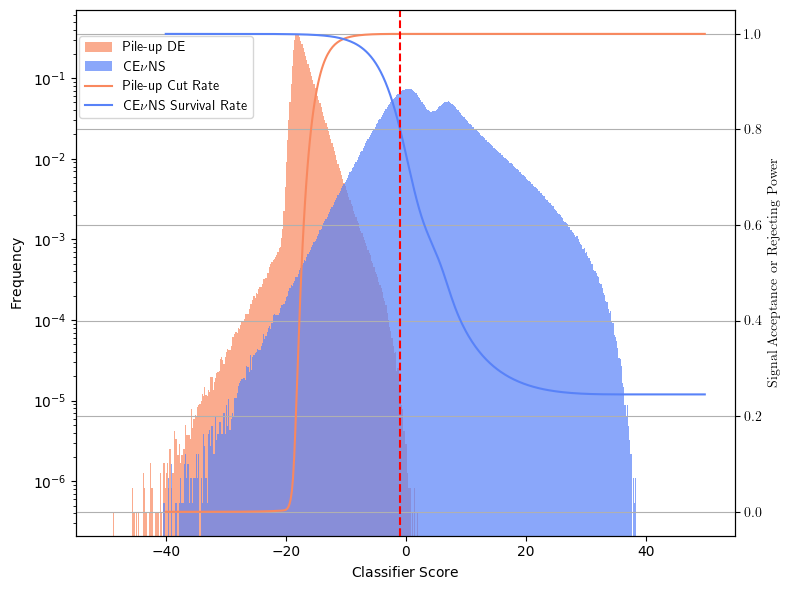

In [ ]:
# 导入所需要的库
import matplotlib.pyplot as plt
import numpy as np

cevns_color = '#5882F8'
DE_color = '#F9885E'

# 创建一个新的图形并设置大小
fig, ax1 = plt.subplots(figsize=(8,6))
plt.rcParams['text.usetex'] = True

# 开始处理第一个图，使用左侧y轴

color = 'tab:blue'
bins = np.arange(-50, 40, 0.2)

ax1.hist(score_DE, bins=bins, log=True, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
ax1.hist(score_CEvNS, bins=bins, log=True, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
ax1.set_xlabel(r'$\mathrm{Classifier\ Score}$')  # x轴标签
ax1.tick_params(axis='y')  # y轴标签颜色

# 第二个图，使用右侧y轴
ax2 = ax1.twinx() 
ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance\ or\ Rejecting\ Power}$')  # 左侧y轴标签
ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
ax2.plot(thresholds, right_cevns_ratios, label=r'CE$\nu$NS Survival Rate', color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
ax2.grid(True)
ax2.tick_params(axis='y')  # y轴标签颜色


# 获得所有子图的 legend labels 和 handles
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 创建一个全局的legend
fig.legend(lines + lines2, labels + labels2, loc=(0.10,0.80))
# fig.legend(lines, labels, loc=(0.17,0.8))

# fig.tight_layout(pad = 5)  # 使布局紧密
# plt.title('Pattern Classifier', fontsize=16)  # 图表标题

plt.axvline(x=thresholds[index], color='red', linestyle='dashed')
plt.tight_layout() 
# plt.savefig("classifier_score.png")
plt.show()  # 显示绘图


Selected threshold: -1.000
Annual rate: 6496.42 events/yr


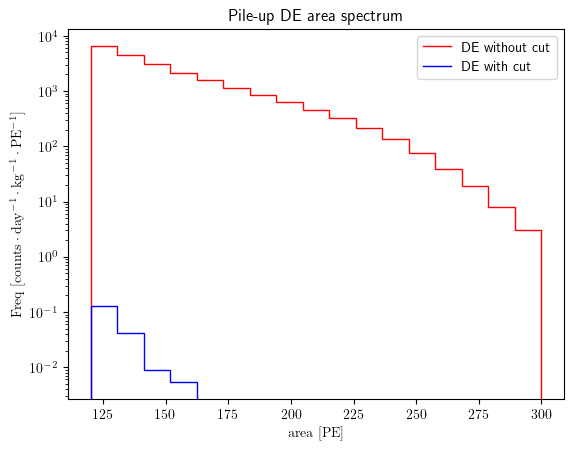

In [ ]:
sel_thres = thresholds[index]
print(f"Selected threshold: {sel_thres:.3f}")
DE_cut = score_DE > sel_thres

bins = np.linspace(120,300,18)

plot_area_spectrum(DE_area[DE_ROI_mask], total_time, LXe_mass=8.98, bins=bins, label='DE without cut', color='red')
plot_area_spectrum(DE_area[DE_ROI_mask][DE_cut], total_time, LXe_mass=8.98, bins=bins, label='DE with cut', color='blue')
plt.yscale('log')
plt.legend()
plt.title('Pile-up DE area spectrum')

print(f"Annual rate: {(len(DE_area[DE_ROI_mask][DE_cut])/total_time)*3600*24*365:.2f} events/yr")

In [ ]:
len(DE_area[DE_ROI_mask][DE_cut])

103

In [ ]:
from tqdm import tqdm

# ============================================================
# 适配当前数据的 score：
#   score = pattern - k_st * log(st_cor) + k_area * area
# 当前 npz 中的 st_cor 是原始值，因此与 legacy 代码一致先取 log。
# ============================================================
def calculate_score_3d(pattern, log_st_cor, area, k_st, k_area):
    return pattern - k_st * log_st_cor + k_area * area


# ROI + 合法样本；st_cor 必须大于 0 才能取 log。
DE_roi_mask = (
    DE_ROI_mask
    & (st_cor > 0)
    & np.isfinite(st_cor)
    & np.isfinite(pattern)
    & np.isfinite(DE_area)
)
cevns_roi_mask = (
    cevns_ROI_mask
    & (cevns_st_cor > 0)
    & np.isfinite(cevns_st_cor)
    & np.isfinite(cevns_pattern)
    & np.isfinite(cevns_area)
)

DE_log_st_cor_roi = np.log(st_cor[DE_roi_mask])
DE_pattern_roi = pattern[DE_roi_mask]
DE_area_roi = DE_area[DE_roi_mask]

cevns_log_st_cor_roi = np.log(cevns_st_cor[cevns_roi_mask])
cevns_pattern_roi = cevns_pattern[cevns_roi_mask]
cevns_area_roi = cevns_area[cevns_roi_mask]

print("ROI 内事件数: DE =", len(DE_area_roi), ", CEvNS =", len(cevns_area_roi))

# 参数扫描：约束 DE 泄漏率为 0.001，最大化 CEvNS exposure。
k_st_list = np.arange(0, 50, 0.5)
k_area_list = np.arange(0, 2.5, 0.025)
exposure = np.full((len(k_st_list), len(k_area_list)), np.nan)

best_exposure = -np.inf
best_k_st = None
best_k_area = None
best_score_thr = None

for i, k_st in enumerate(tqdm(k_st_list, desc="scan k_st")):
    for j, k_area in enumerate(k_area_list):
        score_DE = calculate_score_3d(
            DE_pattern_roi, DE_log_st_cor_roi, DE_area_roi, k_st, k_area
        )
        score_cevns = calculate_score_3d(
            cevns_pattern_roi, cevns_log_st_cor_roi, cevns_area_roi, k_st, k_area
        )

        valid_DE = np.isfinite(score_DE)
        valid_cevns = np.isfinite(score_cevns)
        if valid_DE.sum() < 2 or valid_cevns.sum() < 2:
            continue

        score_thr = np.percentile(score_DE[valid_DE], 100 - 0.001)
        survival = np.mean(score_cevns[valid_cevns] > score_thr)
        exposure[i, j] = survival

        if survival > best_exposure:
            best_exposure = float(survival)
            best_k_st = float(k_st)
            best_k_area = float(k_area)
            best_score_thr = float(score_thr)

assert best_k_st is not None, "ROI 内没有足够的有效事件，请检查数据与 mask。"
print(f"最优参数: k_st={best_k_st:.4f}, k_area={best_k_area:.4f}, "
      f"DE 99.999% score 分位={best_score_thr:.4f}, CEvNS exposure={best_exposure:.6f}")

# 参数扫描热图
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(
    exposure,
    origin="lower",
    aspect="auto",
    extent=[k_area_list[0], k_area_list[-1], k_st_list[0], k_st_list[-1]],
)
ax.set_xlabel("k_area")
ax.set_ylabel("k_st")
ax.set_title("CEvNS exposure vs score coefficients")
fig.colorbar(im, ax=ax, label="Exposure")
ax.scatter([best_k_area], [best_k_st], marker="*", color="red", s=160,
           label=f"best ({best_k_st:.2f}, {best_k_area:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

# 用最优参数计算最终 score
score_DE = calculate_score_3d(
    DE_pattern_roi, DE_log_st_cor_roi, DE_area_roi, best_k_st, best_k_area
)
score_CEvNS = calculate_score_3d(
    cevns_pattern_roi, cevns_log_st_cor_roi, cevns_area_roi, best_k_st, best_k_area
)

# 丢弃非有限值，并同步裁剪 area，便于之后画谱。
DE_finite = np.isfinite(score_DE)
cevns_finite = np.isfinite(score_CEvNS)
score_DE = score_DE[DE_finite]
score_CEvNS = score_CEvNS[cevns_finite]
DE_area_final = DE_area_roi[DE_finite]
cevns_area_final = cevns_area_roi[cevns_finite]

# 阈值扫描：DE 低于阈值表示被 cut，CEvNS 高于阈值表示存活。
thresholds = np.linspace(
    min(score_DE.min(), score_CEvNS.min()) - 1,
    max(score_DE.max(), score_CEvNS.max()) + 1,
    500,
)
left_DE_ratios = []
right_cevns_ratios = []
for threshold in thresholds:
    left_DE_ratios.append(np.mean(score_DE < threshold))
    right_cevns_ratios.append(np.mean(score_CEvNS > threshold))
left_DE_ratios = np.array(left_DE_ratios)
right_cevns_ratios = np.array(right_cevns_ratios)

# 选取 DE 泄漏率首次达到 1-1e-5 的阈值
target_leakage = 1 - 1e-5
sel_indices = np.where(left_DE_ratios >= target_leakage)[0]
if len(sel_indices):
    sel_idx = int(sel_indices[0])
else:
    sel_idx = -1
assert sel_idx >= 0, "当前样本量不足以达到 1-1e-5 的 DE 泄漏率阈值，请增大样本。"
sel_thres = float(thresholds[sel_idx])
print(f"选择阈值: sel_thres={sel_thres:.4f} (DE leakage={left_DE_ratios[sel_idx]:.6g}, "
      f"CEvNS survival={right_cevns_ratios[sel_idx]:.6g})")

# 分类器 score 分布与 rejection/survival 曲线
cevns_color = "#5882F8"
DE_color = "#F9885E"

fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.hist(score_DE, bins=80, log=True, label="Pile-up DE",
         alpha=0.7, color=DE_color, density=True)
ax1.hist(score_CEvNS, bins=80, log=True, label=r"CE$\nu$NS",
         alpha=0.7, color=cevns_color, density=True)
ax1.set_xlabel("Classifier Score")
ax1.set_ylabel("Frequency")

ax2 = ax1.twinx()
ax2.set_ylabel("Signal Acceptance or Rejecting Power")
ax2.plot(thresholds, left_DE_ratios, label="Pile-up Cut Rate", color=DE_color)
ax2.plot(thresholds, right_cevns_ratios, label=r"CE$\nu$NS Survival Rate",
         color=cevns_color)
ax2.axvline(sel_thres, color="red", linestyle="--", label="selected threshold")
ax2.grid(True)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines + lines2, labels + labels2, loc=(0.10, 0.72), fontsize=9)
plt.tight_layout()
plt.show()

# 应用 cut 后 DE area 谱与年速率估计
DE_cut = score_DE > sel_thres
bins = np.linspace(120, 300, 18)

plt.figure(figsize=(7, 5))
plot_area_spectrum(
    DE_area_final, total_time, LXe_mass=8.98, bins=bins,
    label="DE without cut", color="red",
)
plot_area_spectrum(
    DE_area_final[DE_cut], total_time, LXe_mass=8.98, bins=bins,
    label="DE with cut", color="blue",
)
plt.yscale("log")
plt.legend()
plt.title("Pile-up DE area spectrum")
plt.tight_layout()
plt.show()

annual_rate = (DE_cut.sum() / total_time) * 3600 * 24 * 365
print(f"cut 后 DE 年速率: {annual_rate:.2f} events/yr")
print(f"cut 前 ROI 事件数: {len(DE_area_final)}, cut 后事件数: {DE_cut.sum()}")
